# 02. Exploratory Data Analysis (EDA)

**เป้าหมายของขั้นนี้**
- เข้าใจ distribution ของแต่ละ feature
- หาความสัมพันธ์ระหว่าง feature กับ Target
- ค้นหา insight ที่จะนำไปใช้ใน Feature Engineering
- ระบุปัญหา (outlier, missing pattern, imbalance) ให้ชัดเจน

**สิ่งที่เราตัดสินใจไว้แล้วจากขั้นก่อน**
- Target = Disaster Type ที่ group แล้ว (9 classes) รวม Volcanic activity
- ทิ้ง Identifier + High missing damage + Disaster* columns
- เก็บ Latitude/Longitude และ Impact features ไว้วิเคราะห์ก่อน

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print('Libraries loaded')

Libraries loaded


## 2.1 เตรียมข้อมูล (ใช้ logic เดียวกับขั้น Data Understanding)

In [17]:
df = pd.read_excel('../data/raw/disaster_prediction_dataset.xlsx')

# สร้าง Target ตาม grouping
grouping_map = {
    'Flood': 'Flood',
    'Glacial lake outburst flood': 'Flood',
    'Mass movement (wet)': 'Landslide',
    'Mass movement (dry)': 'Landslide',
    'Earthquake': 'Earthquake',
    'Impact': 'Earthquake',
    'Epidemic': 'Epidemic',
    'Infestation': 'Epidemic',
    'Animal incident': 'Epidemic',
    'Extreme temperature': 'Extreme temperature',
    'Fog': 'Extreme temperature',
    'Storm': 'Storm',
    'Drought': 'Drought',
    'Wildfire': 'Wildfire',
    'Volcanic activity': 'Volcanic activity',
}

df['Target'] = df['Disaster Type'].map(grouping_map)

# คอลัมน์ที่จะทิ้ง
cols_to_drop = [
    'DisNo.', 'Classification Key', 'External IDs', 'Event Name',
    "Reconstruction Costs ('000 US$)", "Reconstruction Costs, Adjusted ('000 US$)",
    "AID Contribution ('000 US$)", "Insured Damage ('000 US$)", "Insured Damage, Adjusted ('000 US$)",
    'Disaster Group', 'Disaster Subgroup', 'Disaster Type', 'Disaster Subtype'
]

df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

print(f'Shape: {df.shape}')
print(f'Target classes: {df["Target"].nunique()}')
print(df['Target'].value_counts())

Shape: (17756, 35)
Target classes: 9
Target
Flood                  6183
Storm                  5053
Earthquake             1651
Epidemic               1622
Landslide               918
Drought                 803
Extreme temperature     730
Wildfire                514
Volcanic activity       282
Name: count, dtype: int64


## 2.2 Missing Values เชิงลึก

In [18]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

print(missing_df[missing_df['Missing Count'] > 0])

                                   Missing Count  Missing %
River Basin                                16154      90.98
No. Homeless                               15213      85.68
Longitude                                  14923      84.04
Latitude                                   14923      84.04
Associated Types                           13488      75.96
No. Injured                                13102      73.79
Origin                                     13039      73.43
Magnitude                                  12468      70.22
Total Damage, Adjusted ('000 US$)          12119      68.25
Total Damage ('000 US$)                    12041      67.81
GADM Admin Units                            9945      56.01
Admin Units                                 9384      52.85
No. Affected                                7154      40.29
Total Deaths                                4979      28.04
Total Affected                              4563      25.70
Start Day                               

In [19]:
# Missing percentage by Target (ดูว่า missing กระจายสม่ำเสมอไหม)
print('=== Missing % ของ Impact features แยกตาม Target ===')
impact_cols = ['Total Deaths', 'No. Injured', 'No. Affected', 'No. Homeless', 'Total Affected',
               "Total Damage ('000 US$)", "Total Damage, Adjusted ('000 US$)"]

for col in impact_cols:
    if col in df.columns:
        miss_by_target = df.groupby('Target')[col].apply(lambda x: x.isna().mean() * 100).round(1)
        print(f'\n{col}:')
        print(miss_by_target.sort_values(ascending=False))

=== Missing % ของ Impact features แยกตาม Target ===

Total Deaths:
Target
Drought                90.9
Volcanic activity      65.6
Wildfire               52.5
Flood                  26.7
Earthquake             25.3
Storm                  24.8
Epidemic               19.8
Extreme temperature    15.9
Landslide               4.2
Name: Total Deaths, dtype: float64

No. Injured:
Target
Drought                99.9
Epidemic               87.4
Extreme temperature    85.3
Volcanic activity      84.4
Flood                  82.3
Wildfire               72.2
Storm                  67.6
Landslide              67.3
Earthquake             32.1
Name: No. Injured, dtype: float64

No. Affected:
Target
Extreme temperature    84.2
Landslide              68.8
Wildfire               54.7
Storm                  51.4
Earthquake             45.7
Drought                31.6
Epidemic               29.5
Flood                  23.9
Volcanic activity      23.0
Name: No. Affected, dtype: float64

No. Homeless:
Target
E

**คำถามให้คิด:**  
Missing ของ `Total Deaths` หรือ `Total Affected` มี pattern ตาม Target ไหม?  
ถ้า class ไหน missing สูงเป็นพิเศษ อาจเป็น signal หรือปัญหา data collection

## 2.3 Univariate - Numerical Features

In [20]:
num_cols = ['Magnitude', 'Latitude', 'Longitude', 'Start Year', 'Start Month', 'Start Day',
            'End Year', 'End Month', 'End Day', 'Total Deaths', 'No. Injured', 'No. Affected',
            'No. Homeless', 'Total Affected', "Total Damage ('000 US$)",
            "Total Damage, Adjusted ('000 US$)", 'CPI']

num_cols = [c for c in num_cols if c in df.columns]

df[num_cols].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Magnitude,5288.0,36666.26,231279.21,-57.00,6.90,144.00,5180.00,1.302587e+07
Latitude,2833.0,18.72,21.63,-72.64,3.30,23.20,36.74,6.793000e+01
Longitude,2833.0,39.72,77.33,-178.25,-0.10,49.41,102.83,1.796500e+02
Start Year,17756.0,1999.54,21.01,1900.00,1991.00,2004.00,2015.00,2.026000e+03
Start Month,17384.0,6.46,3.38,1.00,4.00,7.00,9.00,1.200000e+01
Start Day,14155.0,15.22,8.97,1.00,7.00,15.00,23.00,3.100000e+01
End Year,17756.0,1999.59,21.00,1900.00,1991.00,2004.00,2015.00,2.026000e+03
End Month,17091.0,6.61,3.35,1.00,4.00,7.00,9.00,1.200000e+01
End Day,14265.0,15.85,8.90,1.00,8.00,16.00,24.00,3.100000e+01
Total Deaths,12777.0,2566.97,64848.04,1.00,5.00,18.00,60.00,3.700000e+06


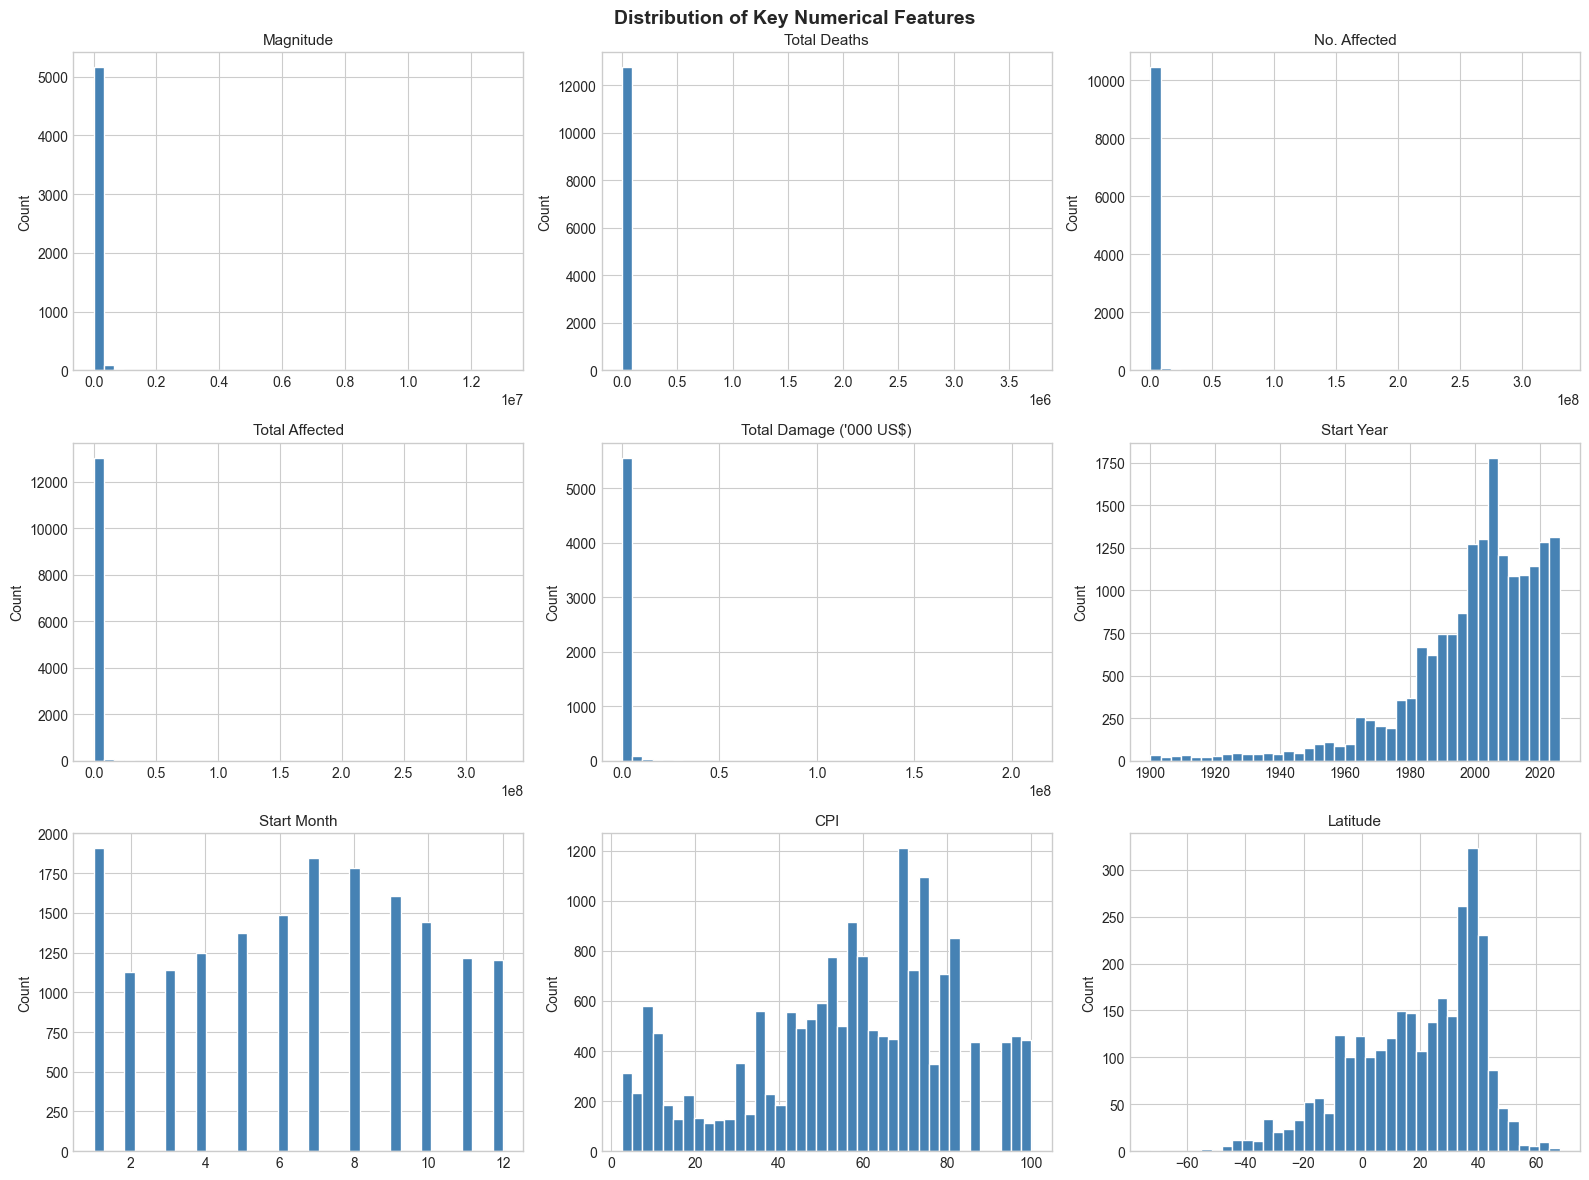

In [21]:
# Distribution ของ numerical สำคัญ ๆ
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

plot_cols = ['Magnitude', 'Total Deaths', 'No. Affected', 'Total Affected',
             "Total Damage ('000 US$)", 'Start Year', 'Start Month', 'CPI', 'Latitude']
plot_cols = [c for c in plot_cols if c in df.columns]

for i, col in enumerate(plot_cols):
    if i < len(axes):
        df[col].dropna().hist(bins=40, ax=axes[i], color='steelblue', edgecolor='white')
        axes[i].set_title(col, fontsize=11)
        axes[i].set_ylabel('Count')

for j in range(len(plot_cols), len(axes)):
    axes[j].axis('off')

plt.suptitle('Distribution of Key Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**สังเกตเบื้องต้นที่ควรหา:**
- `Total Deaths`, `No. Affected`, `Total Damage` มักเป็น right-skewed มาก → อาจต้อง log transform
- `Start Year` กระจายยังไง? มีช่วงปีที่ข้อมูลหนาแน่นเป็นพิเศษไหม?
- `Magnitude` มี scale ต่างกันตามประเภทภัย → ดู `Magnitude Scale` ประกอบ

## 2.4 Univariate - Categorical Features

In [22]:
cat_cols = ['Historic', 'ISO', 'Country', 'Subregion', 'Region', 'Origin',
            'Associated Types', 'OFDA/BHA Response', 'Appeal', 'Declaration',
            'Magnitude Scale', 'River Basin']

cat_cols = [c for c in cat_cols if c in df.columns]

for col in cat_cols:
    nunique = df[col].nunique()
    print(f'\n=== {col} ({nunique} unique, missing {df[col].isna().sum()}) ===')
    print(df[col].value_counts(dropna=False).head(12))


=== Historic (2 unique, missing 0) ===
Historic
No     10708
Yes     7048
Name: count, dtype: int64

=== ISO (230 unique, missing 0) ===
ISO
USA    1211
CHN    1039
IND     804
PHL     730
IDN     660
JPN     403
BGD     372
MEX     313
BRA     301
VNM     288
IRN     270
PAK     262
Name: count, dtype: int64

=== Country (230 unique, missing 0) ===
Country
United States of America      1211
China                         1039
India                          804
Philippines                    730
Indonesia                      660
Japan                          403
Bangladesh                     372
Mexico                         313
Brazil                         301
Viet Nam                       288
Iran (Islamic Republic of)     270
Pakistan                       262
Name: count, dtype: int64

=== Subregion (17 unique, missing 0) ===
Subregion
Latin America and the Caribbean    3051
Sub-Saharan Africa                 2926
Southern Asia                      2246
South-eastern Asia   

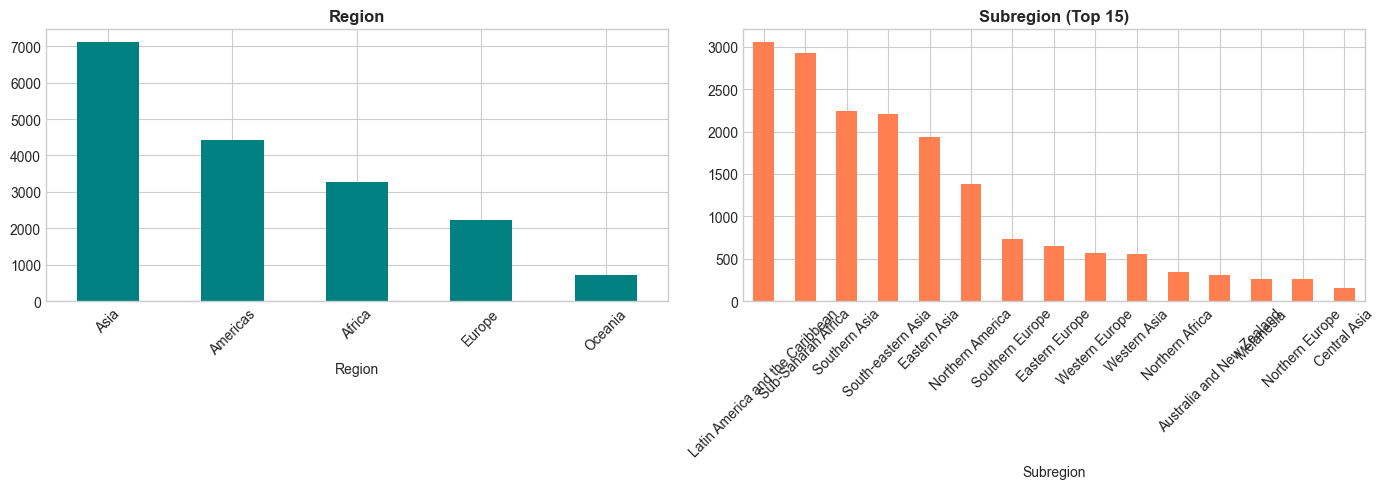

In [23]:
# Region และ Subregion กับจำนวนเหตุการณ์
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['Region'].value_counts().plot(kind='bar', ax=axes[0], color='teal')
axes[0].set_title('Region', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

df['Subregion'].value_counts().head(15).plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Subregion (Top 15)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 2.5 Bivariate Analysis - Feature กับ Target

ส่วนนี้สำคัญที่สุดของ EDA

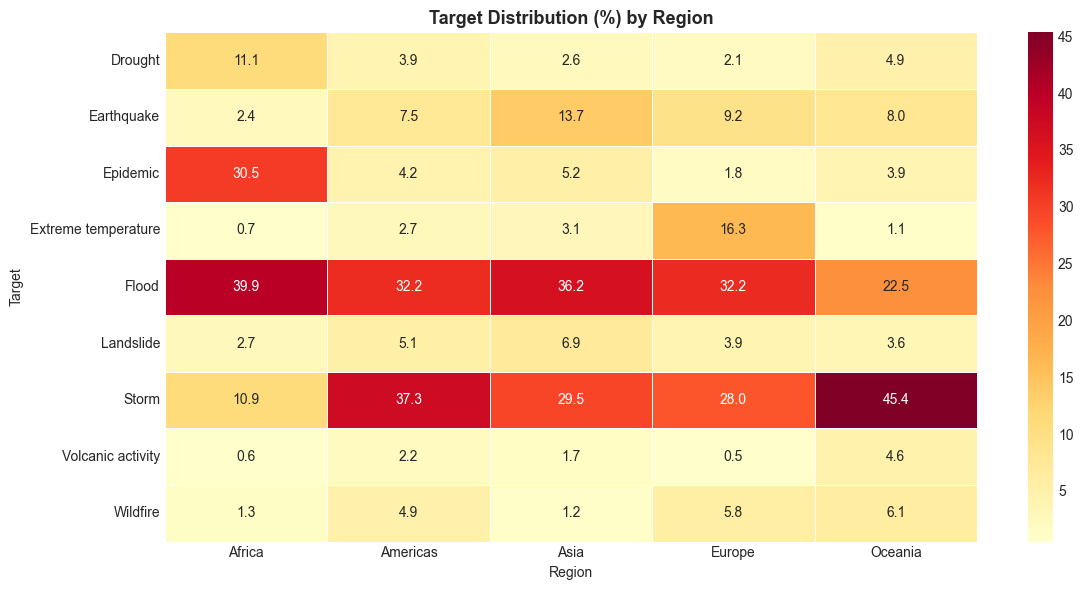

In [24]:
# Target vs Region
ct_region = pd.crosstab(df['Region'], df['Target'], normalize='index') * 100

plt.figure(figsize=(12, 6))
sns.heatmap(ct_region.T, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5)
plt.title('Target Distribution (%) by Region', fontsize=13, fontweight='bold')
plt.xlabel('Region')
plt.ylabel('Target')
plt.tight_layout()
plt.show()

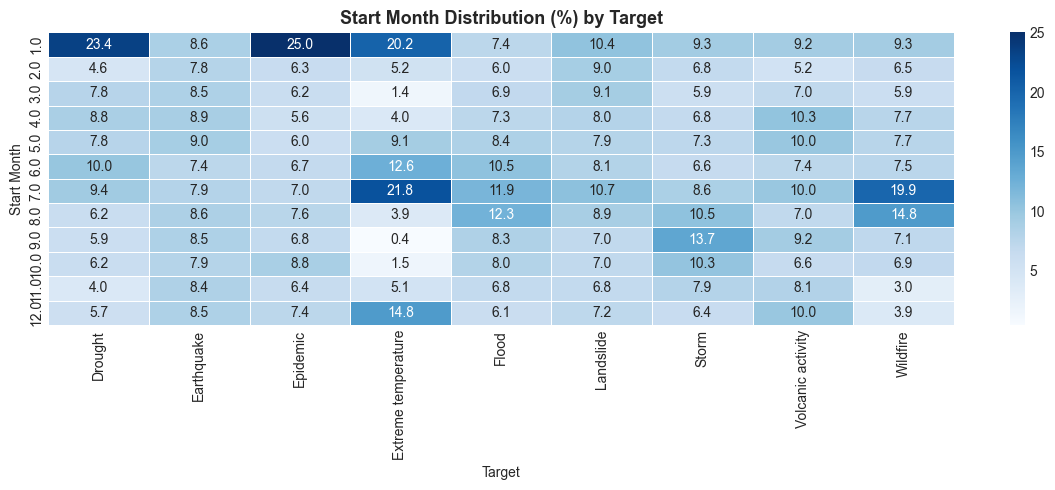

In [25]:
# Target vs Start Month
ct_month = pd.crosstab(df['Start Month'], df['Target'], normalize='columns') * 100

plt.figure(figsize=(12, 5))
sns.heatmap(ct_month, annot=True, fmt='.1f', cmap='Blues', linewidths=0.5)
plt.title('Start Month Distribution (%) by Target', fontsize=13, fontweight='bold')
plt.xlabel('Target')
plt.ylabel('Start Month')
plt.tight_layout()
plt.show()

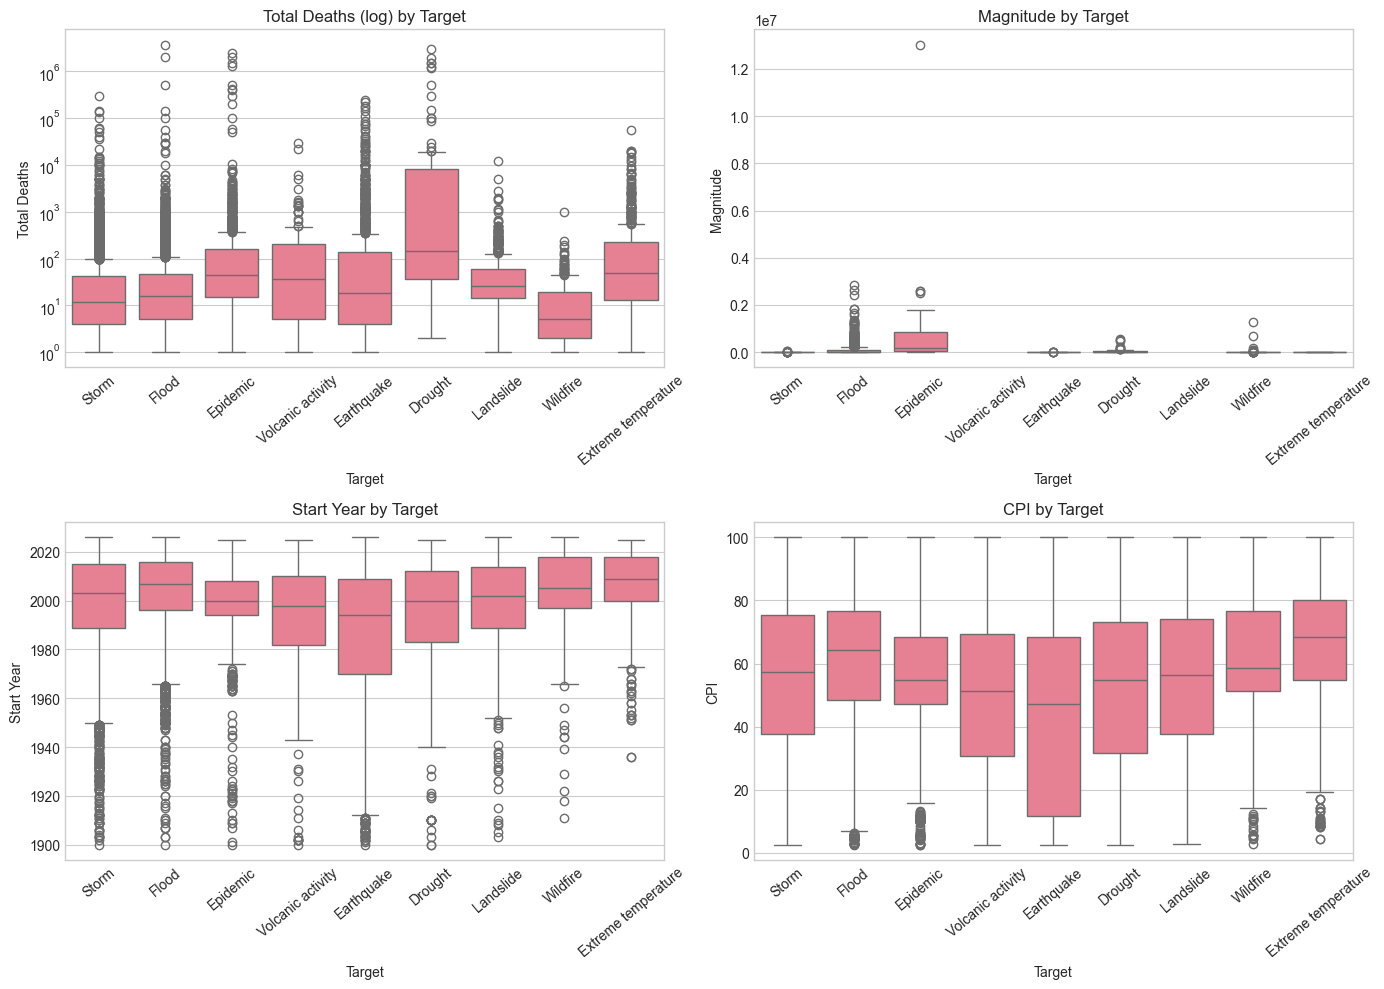

In [26]:
# Boxplot ของ numerical กับ Target (ใช้ log scale สำหรับตัวที่ skewed)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Total Deaths (log)
df_plot = df[df['Total Deaths'] > 0].copy()
sns.boxplot(data=df_plot, x='Target', y='Total Deaths', ax=axes[0, 0])
axes[0, 0].set_yscale('log')
axes[0, 0].set_title('Total Deaths (log) by Target')
axes[0, 0].tick_params(axis='x', rotation=40)

# Magnitude
sns.boxplot(data=df, x='Target', y='Magnitude', ax=axes[0, 1])
axes[0, 1].set_title('Magnitude by Target')
axes[0, 1].tick_params(axis='x', rotation=40)

# Start Year
sns.boxplot(data=df, x='Target', y='Start Year', ax=axes[1, 0])
axes[1, 0].set_title('Start Year by Target')
axes[1, 0].tick_params(axis='x', rotation=40)

# CPI
sns.boxplot(data=df, x='Target', y='CPI', ax=axes[1, 1])
axes[1, 1].set_title('CPI by Target')
axes[1, 1].tick_params(axis='x', rotation=40)

plt.tight_layout()
plt.show()

**คำถามสำคัญให้สังเกตจากกราฟ:**
1. Region ไหนมีสัดส่วน Flood / Storm / Earthquake สูงเป็นพิเศษ?
2. เดือนไหนที่ Drought หรือ Extreme temperature เกิดบ่อย?
3. `Magnitude` แยก class ได้ชัดเจนไหม? (ระวัง scale ต่างกัน)
4. `Total Deaths` ของ Epidemic หรือ Earthquake สูงกว่า class อื่นไหม?

## 2.6 Magnitude Scale กับ Target (สำคัญ)

In [29]:
print('=== Magnitude Scale value counts ===')
print(df['Magnitude Scale'].value_counts(dropna=False))

print('\n=== Magnitude Scale vs Target (count) ===')
print(pd.crosstab(df['Magnitude Scale'], df['Target'], margins=True))
print(df[df['Target'] == 'Volcanic activity']['Magnitude Scale'].value_counts(dropna=False))

=== Magnitude Scale value counts ===
Magnitude Scale
Km2                 7492
Kph                 5053
NaN                 2103
Moment Magnitude    1650
Vaccinated           729
°C                   729
Name: count, dtype: int64

=== Magnitude Scale vs Target (count) ===
Target            Drought  Earthquake  Epidemic  Extreme temperature  Flood  \
Magnitude Scale                                                               
Km2                   803           0         0                    0   6175   
Kph                     0           0         0                    0      0   
Moment Magnitude        0        1650         0                    0      0   
Vaccinated              0           0       729                    0      0   
°C                      0           0         0                  729      0   
All                   803        1650       729                  729   6175   

Target            Storm  Wildfire    All  
Magnitude Scale                           
Km2      

**Insight ที่ควรได้:**  
`Magnitude Scale` มักบอกประเภทภัยได้ค่อนข้างชัด (เช่น Richter → Earthquake, Km2 → Flood/Drought)  
→ อาจเป็น feature ที่ทรงพลัง แต่ต้องระวัง leakage ด้วย

## 2.7 Location Features (Latitude / Longitude)

Latitude missing: 84.0%
Longitude missing: 84.0%

จำนวนแถวที่มีพิกัด: 2,833 (16.0%)


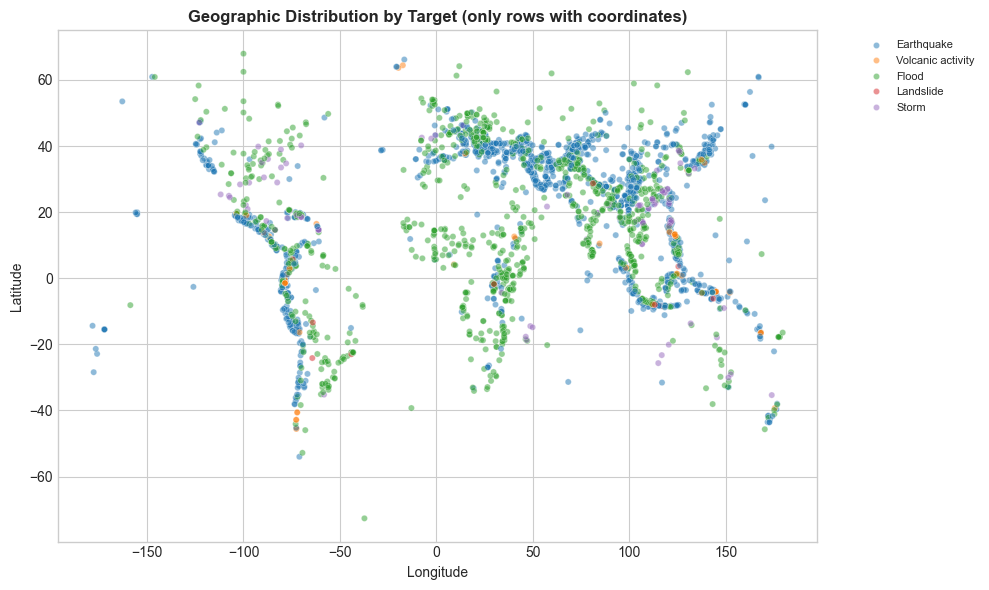

In [28]:
print(f'Latitude missing: {df["Latitude"].isna().mean()*100:.1f}%')
print(f'Longitude missing: {df["Longitude"].isna().mean()*100:.1f}%')

# ดูเฉพาะแถวที่มีพิกัด
df_geo = df.dropna(subset=['Latitude', 'Longitude'])
print(f'\nจำนวนแถวที่มีพิกัด: {len(df_geo):,} ({len(df_geo)/len(df)*100:.1f}%)')

plt.figure(figsize=(10, 6))
scatter = sns.scatterplot(data=df_geo, x='Longitude', y='Latitude', hue='Target',
                          alpha=0.5, s=20, palette='tab10')
plt.title('Geographic Distribution by Target (only rows with coordinates)', fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

## 2.8 สรุป Insight จาก EDA + คำถามให้คุณตอบ

หลังจาก run notebook นี้แล้ว ให้ตอบคำถามเหล่านี้:

1. **Feature ไหนที่ดูมีพลังในการแยก Target ชัดเจนที่สุด?** (จาก heatmap / boxplot)
2. **มี feature ไหนที่ skewed มาก และน่าจะควร log-transform ไหม?**
3. **`Magnitude Scale` ควรเก็บไว้เป็น feature ไหม?** ทำไม?
4. **Latitude/Longitude** แม้ missing สูง ยังพอมีประโยชน์ไหมจาก scatter plot?
5. **มีอะไรที่คุณประหลาดใจหรือสงสัยจากผล EDA บ้าง?**

ตอบมาได้เลย แล้วเราจะไปขั้น **Data Engineering + Feature Engineering** ต่อ